In [480]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

In [481]:
filepath = '/content/drive/MyDrive/IIT Palakkad Advanced AI/Assignments/Dataset/employee_attrition_dataset_10000.csv'
df_emp_attrition = pd.read_csv(filepath)


### 2. Data Understanding

This section gives a quick overview of the dataset, including its structure, features, and basic statistics.

In [482]:
df_emp_attrition.shape

(10000, 26)

In [483]:
df_emp_attrition.describe()

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,39.561800,2.990800,11436.716700,57.032300,14.936200,7.451300,4.471900,2.502400,3.038000,2.507700,49.588900,4.984400,44.473500,9.410200,2.493100,2.491400,2.505400,25.272000,2.516600
std,2886.89568,11.454986,1.410643,4926.528302,24.703261,8.431657,4.042903,2.891617,1.112348,1.414764,1.120833,28.801393,2.580043,8.611662,5.760335,1.120927,1.115101,1.116018,14.219474,1.113934
min,1.00000,20.000000,1.000000,3000.000000,15.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,30.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,30.000000,2.000000,7182.500000,36.000000,8.000000,4.000000,2.000000,2.000000,2.000000,2.000000,25.000000,3.000000,37.000000,4.000000,1.000000,1.000000,2.000000,13.000000,2.000000
50%,5000.50000,40.000000,3.000000,11401.500000,57.000000,15.000000,7.000000,4.000000,2.000000,3.000000,3.000000,49.000000,5.000000,45.000000,9.000000,2.000000,2.000000,3.000000,25.000000,2.000000
75%,7500.25000,49.000000,4.000000,15679.500000,78.000000,22.000000,11.000000,7.000000,3.000000,4.000000,4.000000,75.000000,7.000000,52.000000,14.000000,4.000000,3.000000,3.000000,37.000000,4.000000
max,10000.00000,59.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.000000,4.000000,5.000000,4.000000,99.000000,9.000000,59.000000,19.000000,4.000000,4.000000,4.000000,49.000000,4.000000


In [484]:
df_emp_attrition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    10000 non-null  int64 
 1   Age                            10000 non-null  int64 
 2   Gender                         10000 non-null  object
 3   Marital_Status                 10000 non-null  object
 4   Department                     10000 non-null  object
 5   Job_Role                       10000 non-null  object
 6   Job_Level                      10000 non-null  int64 
 7   Monthly_Income                 10000 non-null  int64 
 8   Hourly_Rate                    10000 non-null  int64 
 9   Years_at_Company               10000 non-null  int64 
 10  Years_in_Current_Role          10000 non-null  int64 
 11  Years_Since_Last_Promotion     10000 non-null  int64 
 12  Work_Life_Balance              10000 non-null  int64 
 13  Jo

In [485]:
df_emp_attrition.head(10)

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,No,1,54,11,1,1,1,43,4,No
5,6,58,Male,Married,Finance,Executive,3,7305,63,25,...,No,1,42,11,2,3,4,4,3,Yes
6,7,38,Male,Married,Sales,Executive,5,15697,63,3,...,No,1,58,16,3,3,4,33,1,Yes
7,8,42,Female,Married,Marketing,Executive,1,14506,41,16,...,Yes,3,45,9,2,1,4,3,2,No
8,9,30,Female,Married,IT,Analyst,4,18105,95,17,...,Yes,8,42,4,3,3,1,39,4,No
9,10,30,Male,Divorced,Sales,Assistant,4,15745,53,16,...,Yes,6,41,12,4,2,1,1,4,No


### 3. Exploratory Data Analysis (EDA)

Extracting the numerical columns in the dataset (also removing Employee_ID column):

In [486]:
num_cols = [column for column in df_emp_attrition.columns if df_emp_attrition[column].dtype != 'O']
num_cols

['Employee_ID',
 'Age',
 'Job_Level',
 'Monthly_Income',
 'Hourly_Rate',
 'Years_at_Company',
 'Years_in_Current_Role',
 'Years_Since_Last_Promotion',
 'Work_Life_Balance',
 'Job_Satisfaction',
 'Performance_Rating',
 'Training_Hours_Last_Year',
 'Project_Count',
 'Average_Hours_Worked_Per_Week',
 'Absenteeism',
 'Work_Environment_Satisfaction',
 'Relationship_with_Manager',
 'Job_Involvement',
 'Distance_From_Home',
 'Number_of_Companies_Worked']

In [487]:
cat_cols = [column for column in df_emp_attrition.columns if df_emp_attrition[column].dtype == 'O']
cat_cols

['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime', 'Attrition']

In [488]:
df_emp_attrition[num_cols].shape

(10000, 20)

#### Univariate Analysis

Performing univariate analysis for numerical columns:

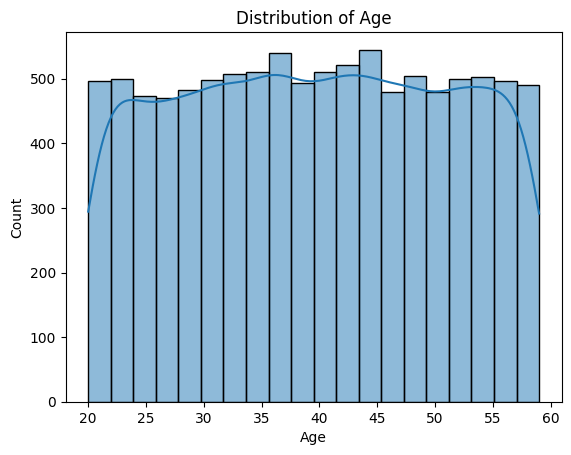

In [489]:
sns.histplot(df_emp_attrition['Age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [490]:
df_emp_attrition['Age'].skew()

np.float64(-0.009570809871093417)

The Age distribution is approximately symmetric and close to a normal distribution, as the skewness value is near zero.


Distribution of numerical columns:

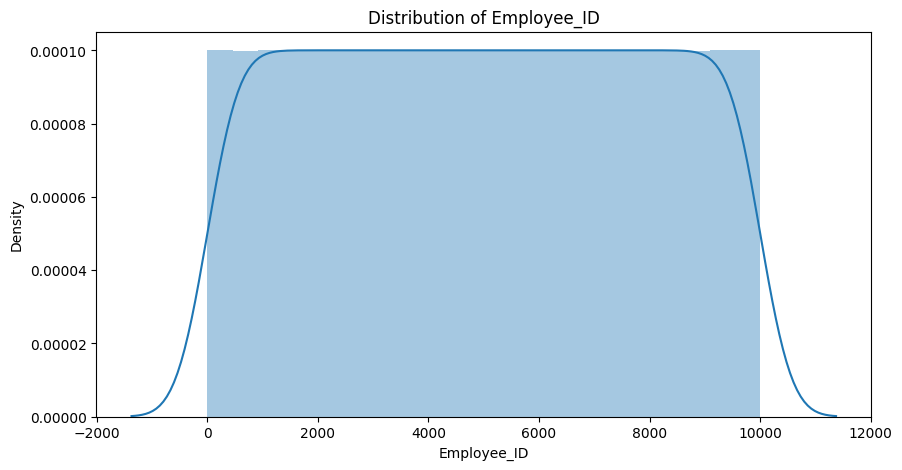

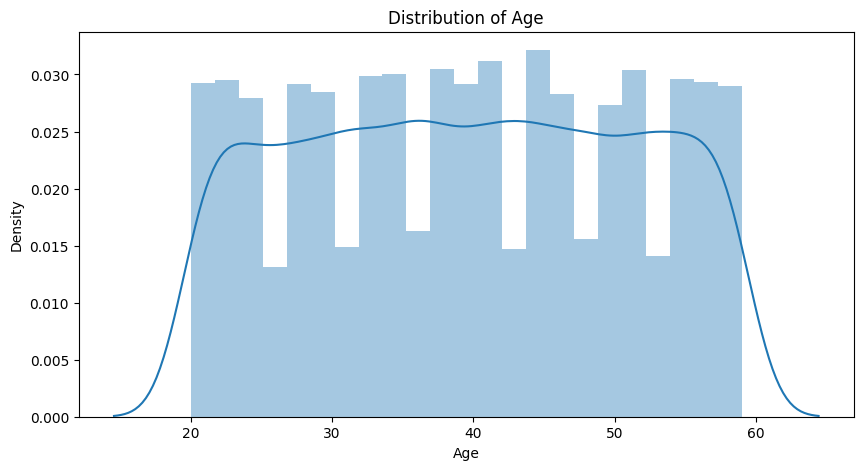

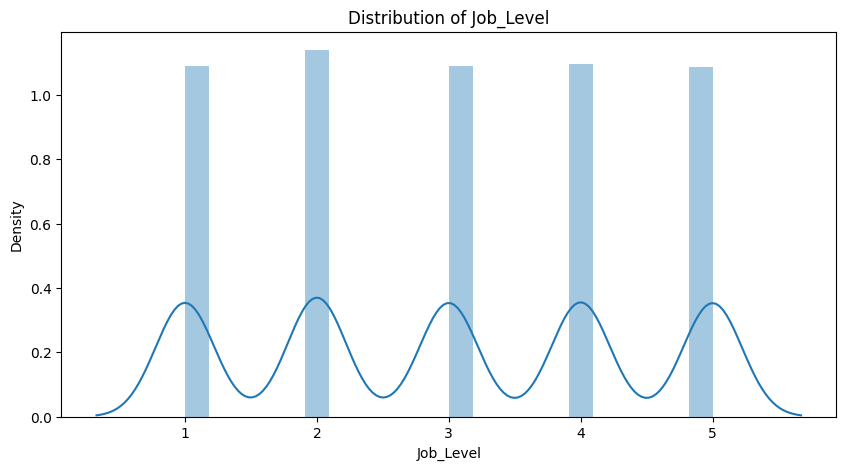

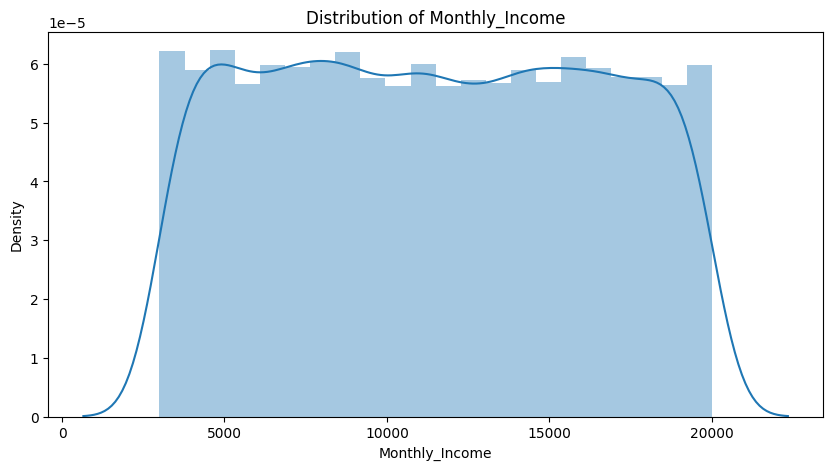

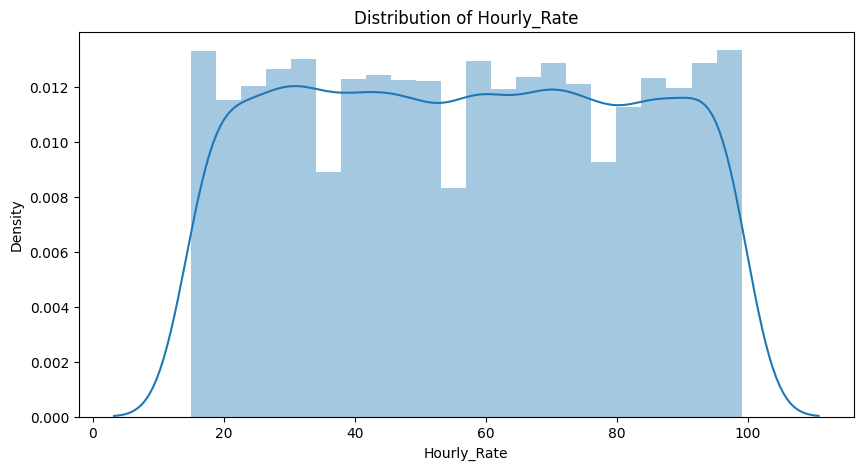

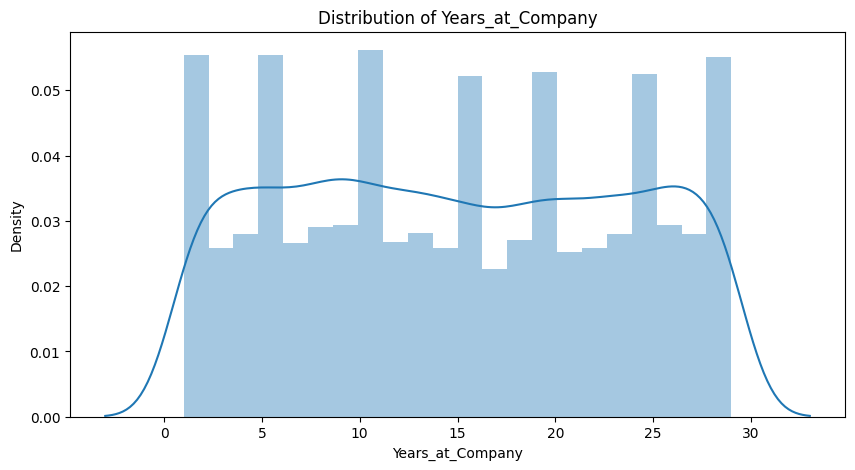

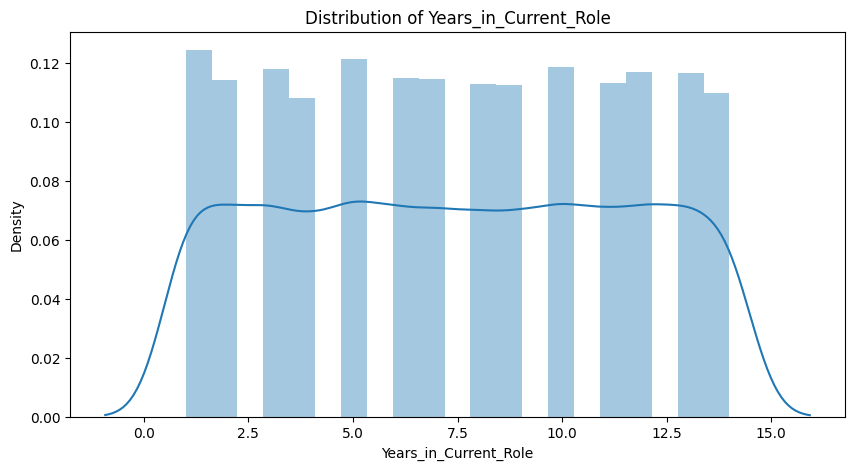

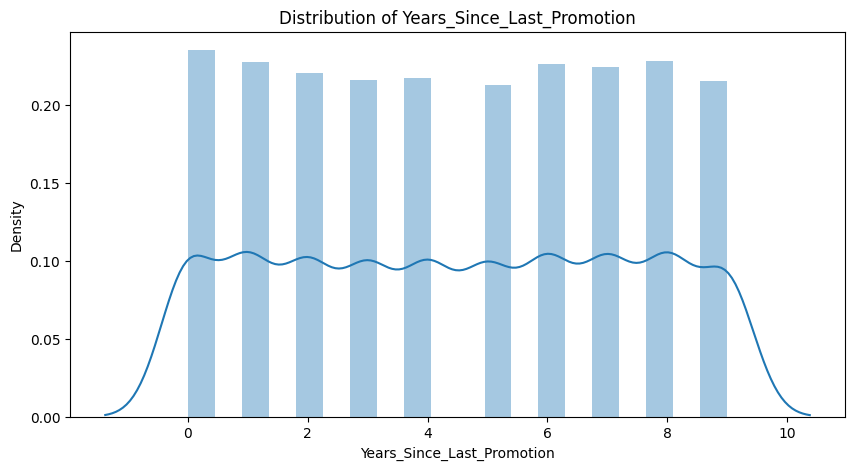

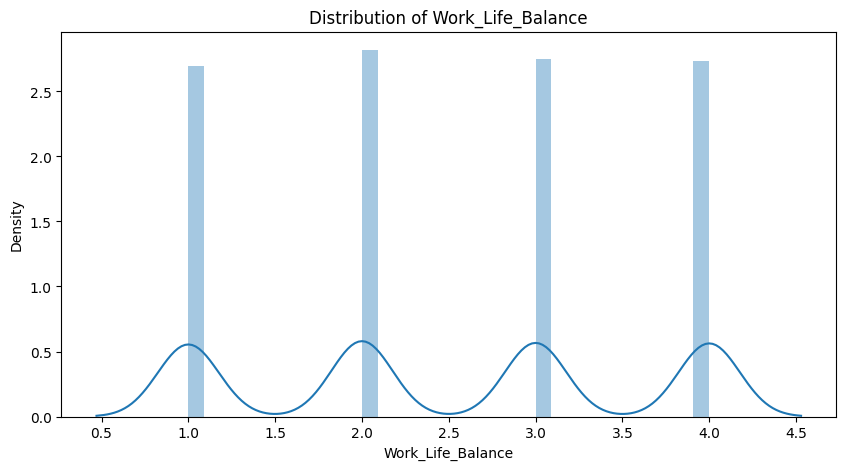

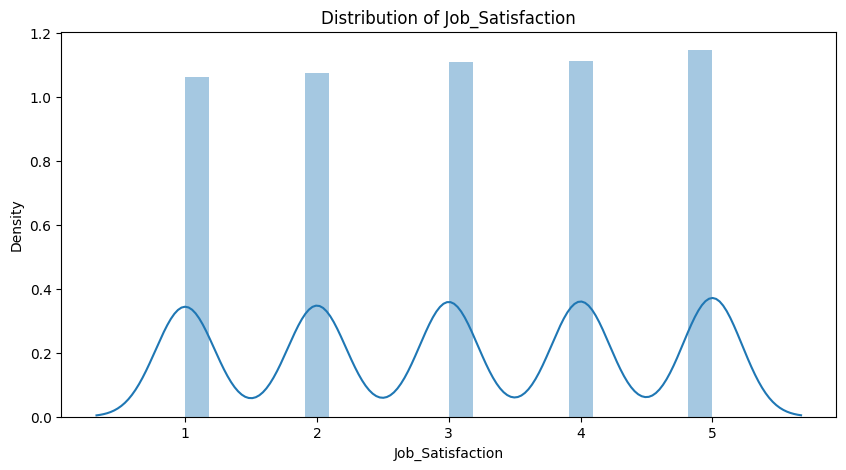

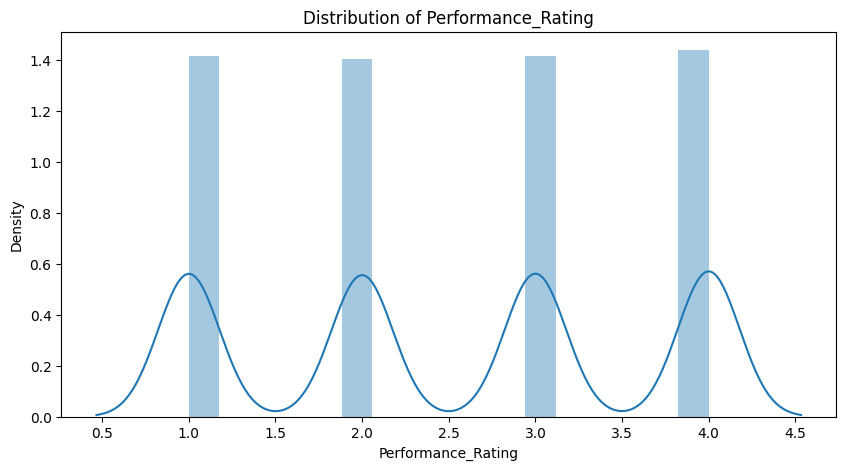

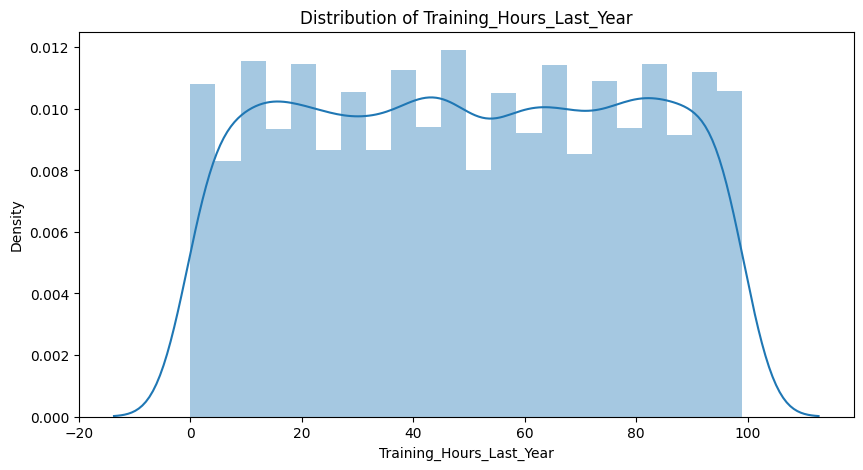

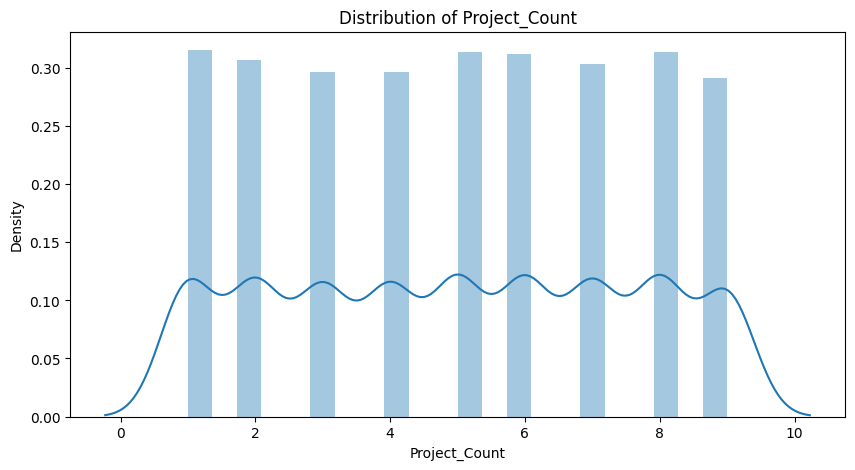

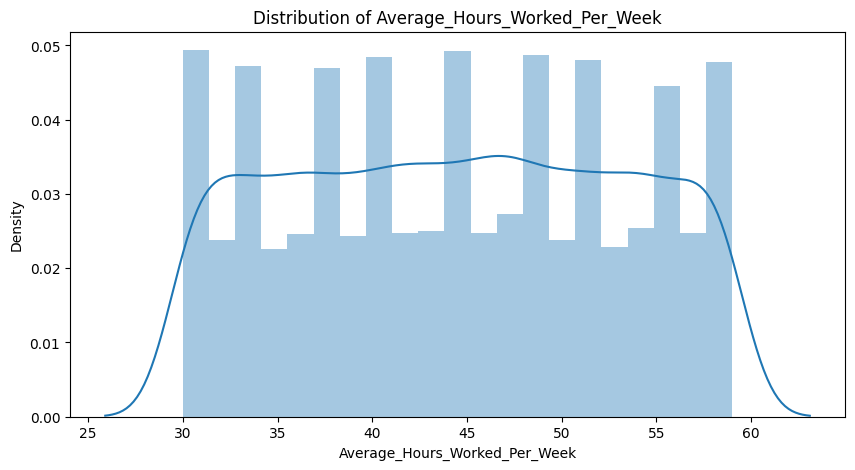

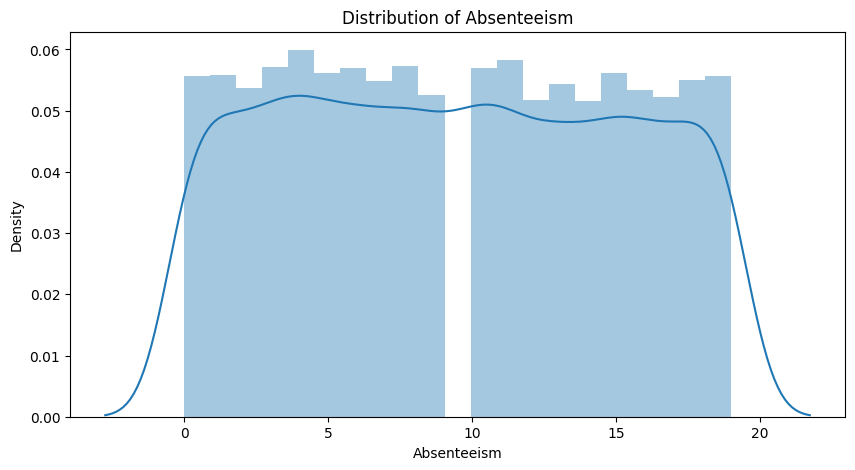

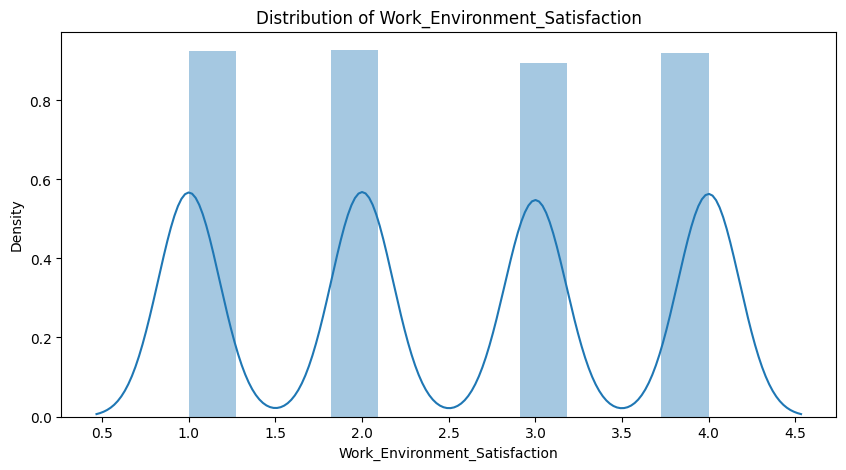

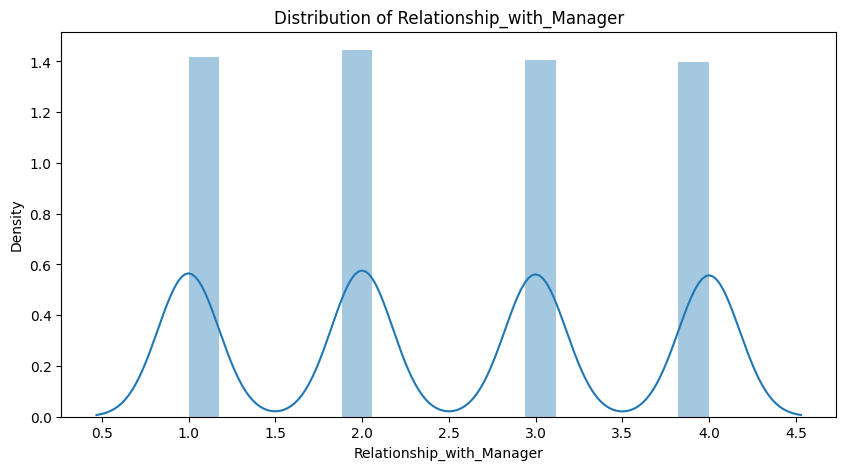

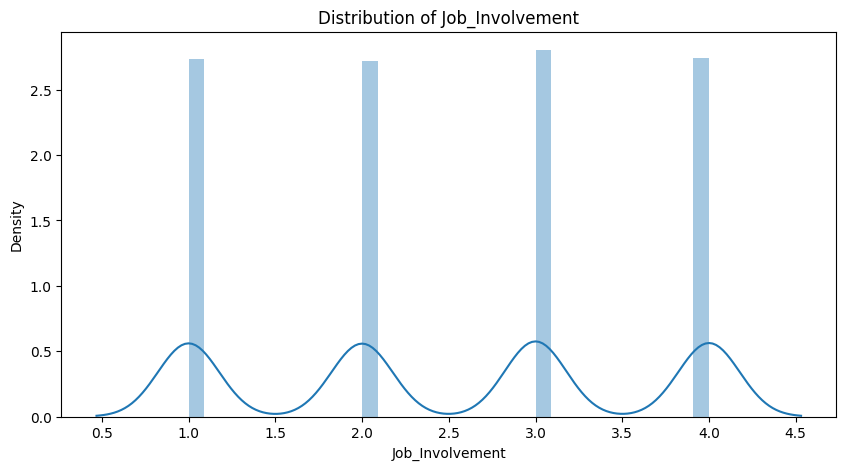

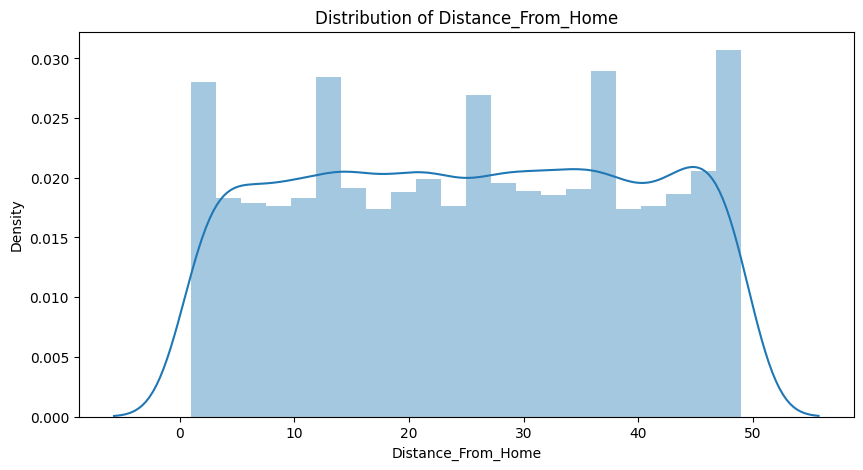

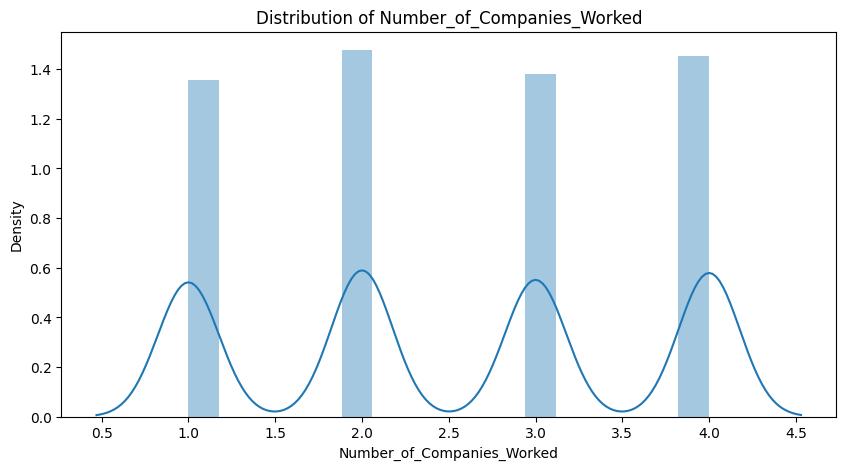

In [491]:
for column in num_cols:
  plt.figure(figsize=(10,5))
  sns.distplot(df_emp_attrition[column])
  plt.title(f'Distribution of {column}')
  plt.show()

All of the numerical columns are approximately symmetric and close to a normal distribution.


Boxplot of numerical columns:

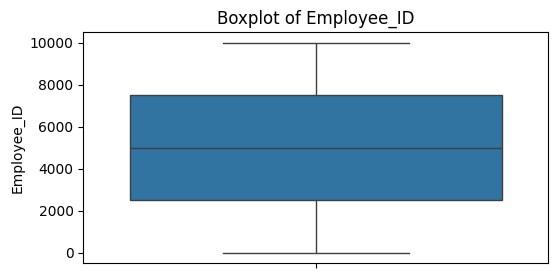

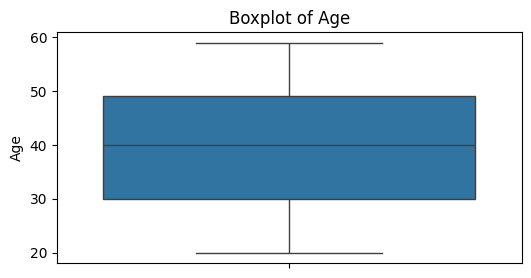

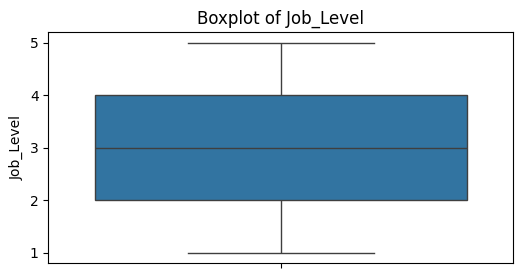

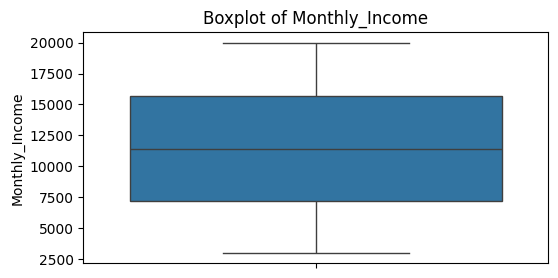

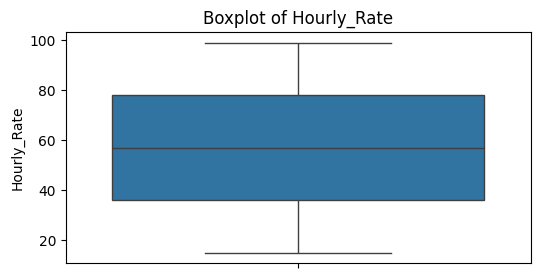

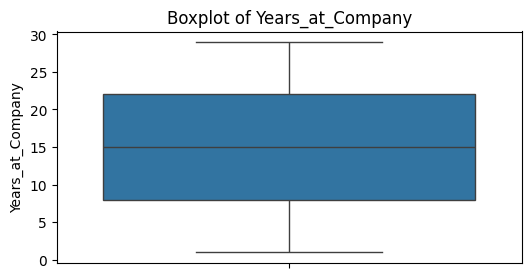

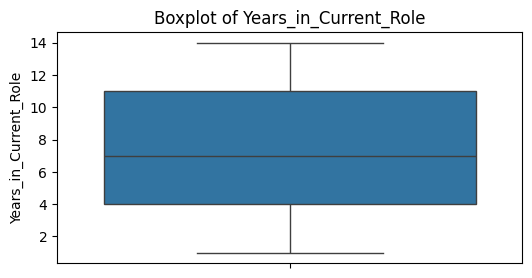

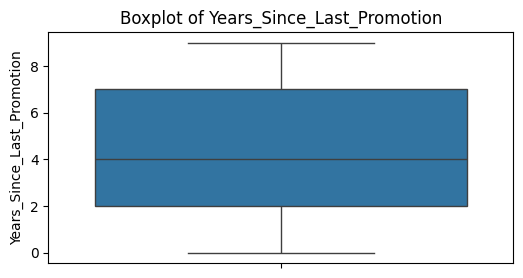

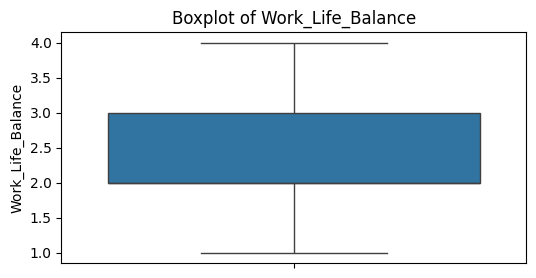

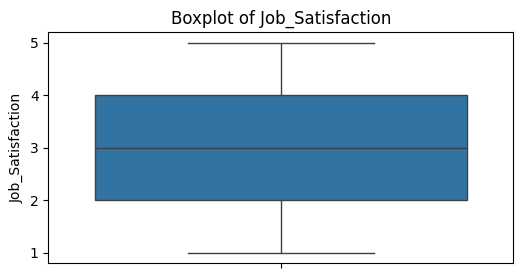

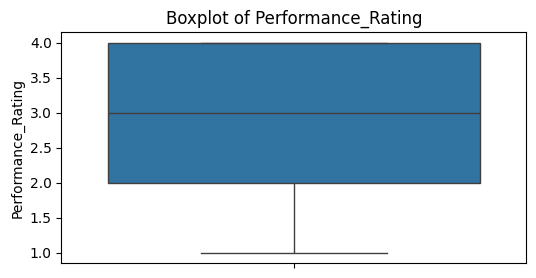

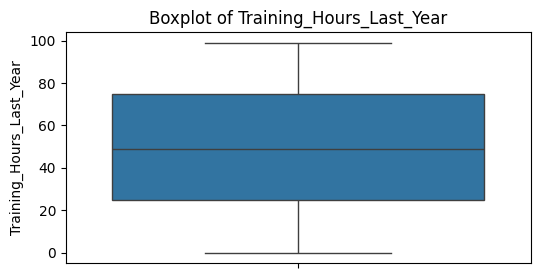

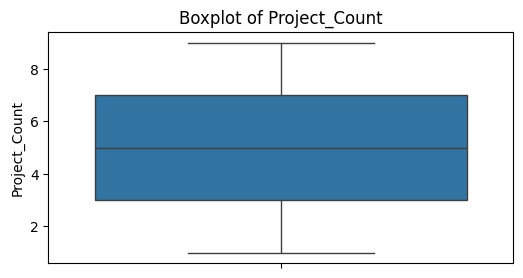

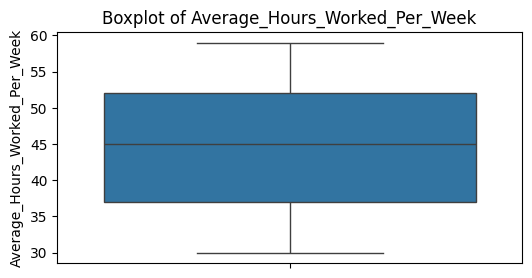

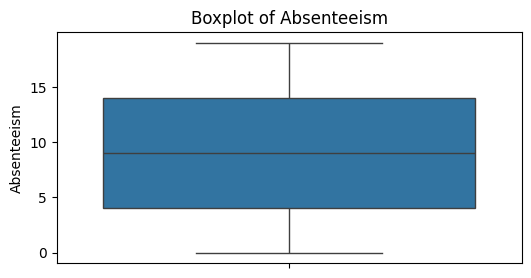

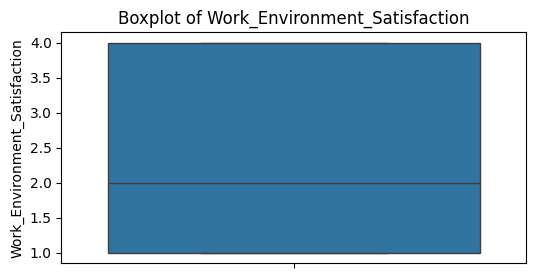

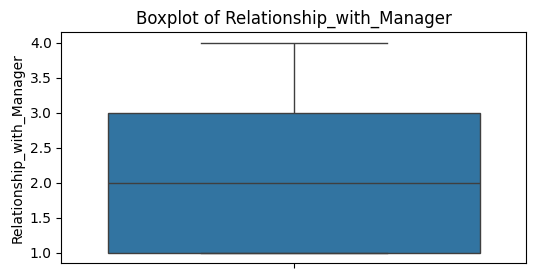

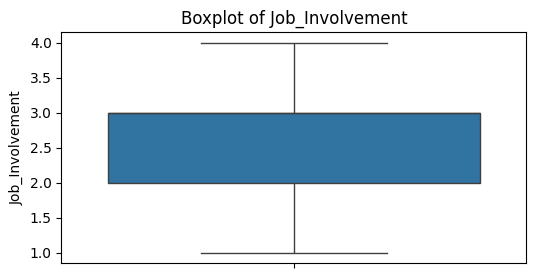

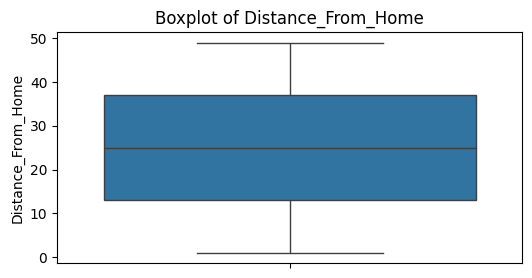

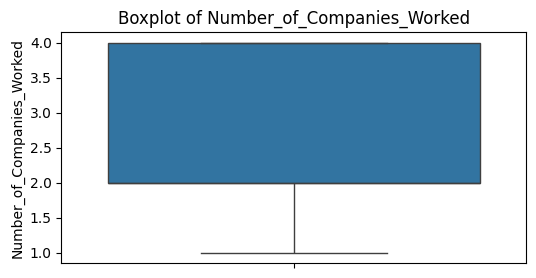

In [492]:
for column in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(df_emp_attrition[column])
    plt.title(f'Boxplot of {column}')
    plt.show()


From the above plots it is clear that there are no outliers in any of the numerical columns.

Performing univariate analysis for categorical columns:

Count plot of categorical columns

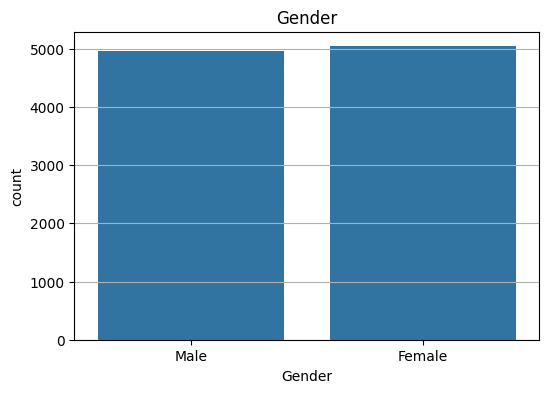

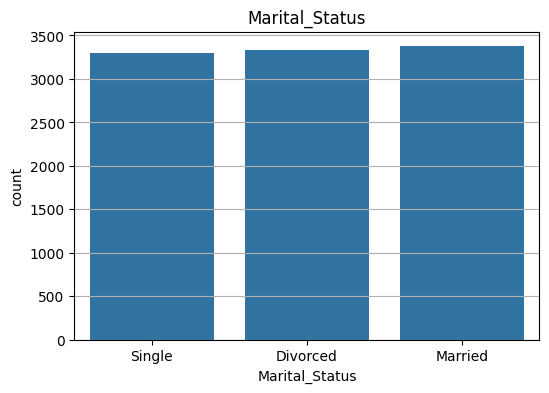

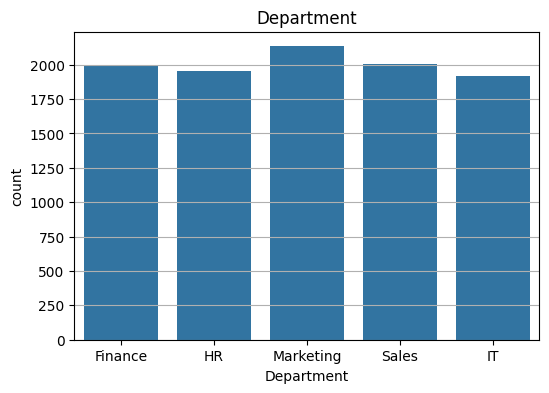

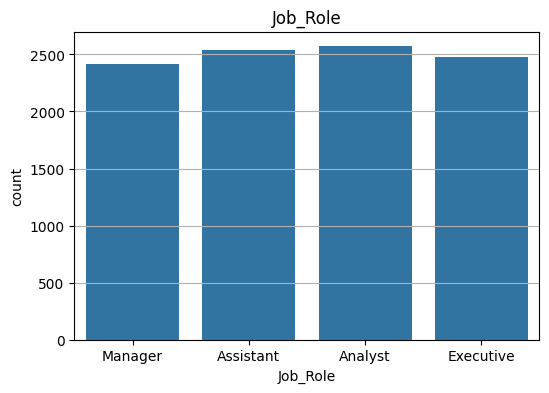

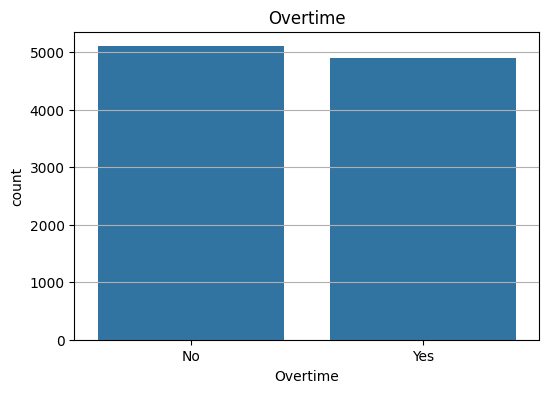

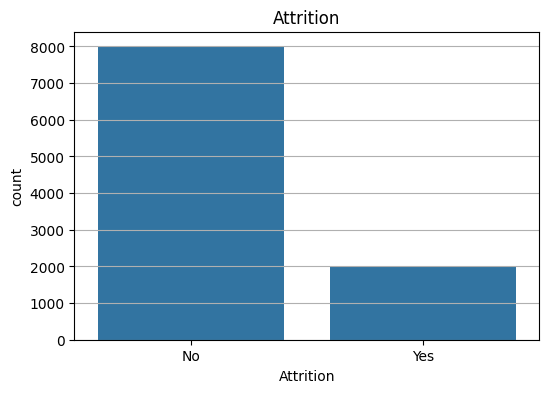

In [493]:
for column in cat_cols:
  plt.figure(figsize=(6, 4))
  plt.grid()
  sns.countplot(x=column, data=df_emp_attrition)
  plt.title(column)
  plt.show()

The distribution of categorical features such as Gender, Job_Role, Overtime, etc.. appears relatively balanced across categories, with nearly equal counts for each class. However, the target variable 'Attrition' is imbalanced, as the number of 'No' observations is significantly higher than the number of 'Yes' observations. This indicates that while the predictor categories are fairly uniform, the response variable shows a class imbalance that may need to be considered during model building and evaluation.

##### Attrition distribution

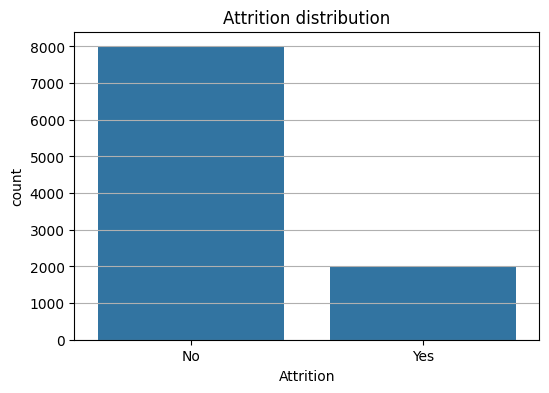

In [494]:
plt.figure(figsize=(6, 4))
plt.grid()
sns.countplot(x='Attrition', data=df_emp_attrition)
plt.title('Attrition distribution')
plt.show()

In [495]:
df_emp_attrition.groupby('Attrition').size() / len(df_emp_attrition) * 100

,0
Attrition,
No,80.03
Yes,19.97


The plot shows a severe class imbalance (80:20 ratio) between employees who stayed ("No" $\approx 8,000$) and those who left ("Yes" $\approx 2,000$).

This imbalance can affect the model because it may learn to favor the majority class (No) and perform poorly at identifying the minority class (Yes). As a result, the model might achieve high overall accuracy while still making many mistakes on the less frequent class.

#### Bi-Variate Analysis

<Axes: xlabel='Gender'>

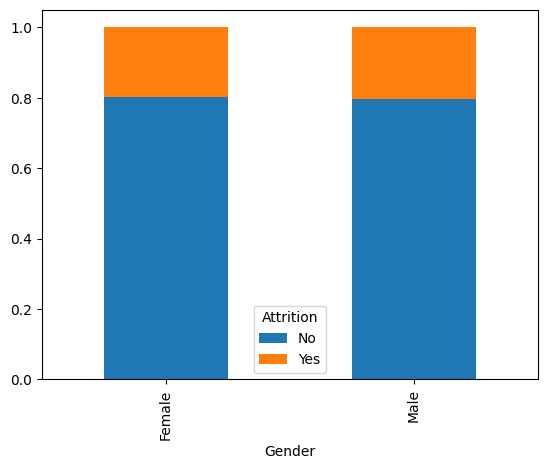

In [496]:
pd.crosstab(df_emp_attrition['Gender'], df_emp_attrition['Attrition'], normalize='index').plot(kind='bar', stacked=True)


In [497]:
pd.crosstab(df_emp_attrition['Gender'], df_emp_attrition['Attrition'], normalize='index') * 100


Attrition,No,Yes
Gender,,
Female,80.325268,19.674732
Male,79.729730,20.270270


It is clear from the above plot that the Attrition rate is almost the same for Male and Female. So the Gender feature may not have much weightsge in the prediction or output of the Attrition

<Axes: xlabel='Marital_Status'>

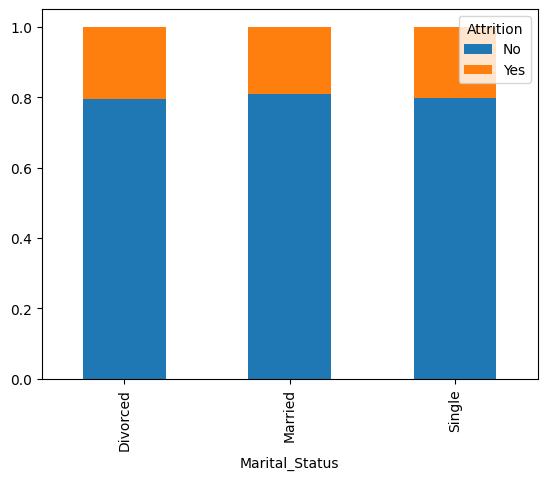

In [498]:
pd.crosstab(df_emp_attrition['Marital_Status'], df_emp_attrition['Attrition'], normalize='index').plot(kind='bar', stacked=True)


In [499]:
pd.crosstab(df_emp_attrition['Marital_Status'], df_emp_attrition['Attrition'], normalize='index') * 100


Attrition,No,Yes
Marital_Status,,
Divorced,79.459459,20.540541
Married,80.770370,19.229630
Single,79.848255,20.151745


It is clear from the above plot that the Attrition rate is almost the same among Divorced, Married and Single. So the Gender feature may not have much weightsge in the prediction or output of the Attrition.

##### Attrition by Department

<Axes: xlabel='Department'>

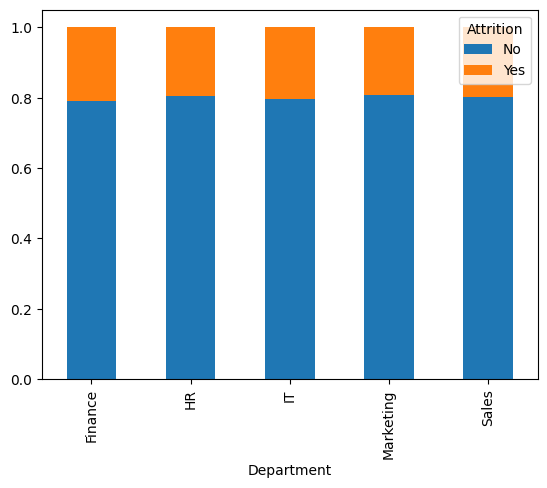

In [500]:
pd.crosstab(df_emp_attrition['Department'], df_emp_attrition['Attrition'], normalize='index').plot(kind='bar', stacked=True)


In [501]:
pd.crosstab(df_emp_attrition['Department'], df_emp_attrition['Attrition'], normalize='index') * 100


Attrition,No,Yes
Department,,
Finance,79.145729,20.854271
HR,80.491551,19.508449
IT,79.645094,20.354906
Marketing,80.637600,19.362400
Sales,80.179283,19.820717


It is clear from the above plot that the Attrition rate is almost the same among each class of Department feature. So the Department feature may not have much weightsge in the prediction or output of the Attrition.

<Axes: xlabel='Job_Role'>

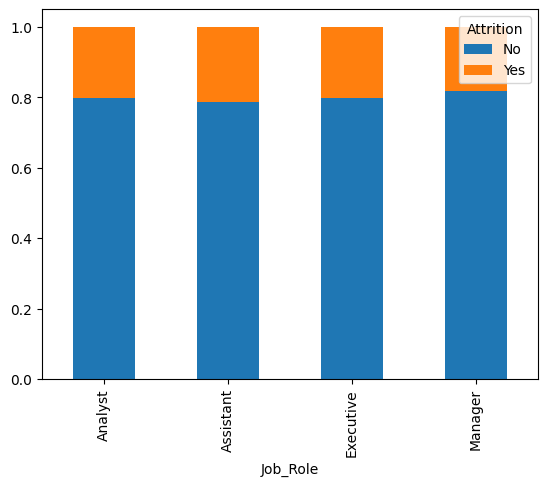

In [502]:
pd.crosstab(df_emp_attrition['Job_Role'], df_emp_attrition['Attrition'], normalize='index').plot(kind='bar', stacked=True)


In [503]:
pd.crosstab(df_emp_attrition['Job_Role'], df_emp_attrition['Attrition'], normalize='index') * 100


Attrition,No,Yes
Job_Role,,
Analyst,79.782271,20.217729
Assistant,78.565800,21.434200
Executive,79.927302,20.072698
Manager,81.938691,18.061309


It is clear from the above plot that the Attrition rate is almost the same among each class of Job_Role. So the Job_Role feature may not have much weightsge in the prediction or output of the Attrition.

##### Attrition by overtime

<Axes: xlabel='Overtime'>

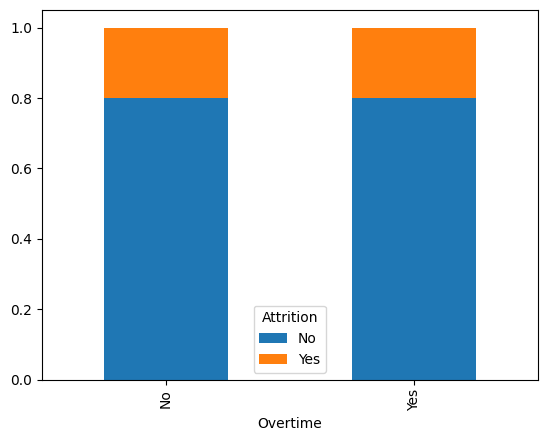

In [504]:
pd.crosstab(df_emp_attrition['Overtime'], df_emp_attrition['Attrition'], normalize='index').plot(kind='bar', stacked=True)


In [505]:
pd.crosstab(df_emp_attrition['Overtime'], df_emp_attrition['Attrition'], normalize='index') * 100


Attrition,No,Yes
Overtime,,
No,80.129336,19.870664
Yes,79.926486,20.073514


It is clear from the above plot that the Attrition rate is almost the same among each class of Overtime. So the Overtime feature may not have much weightsge in the prediction or output of the Attrition.

##### Attrition by Salary

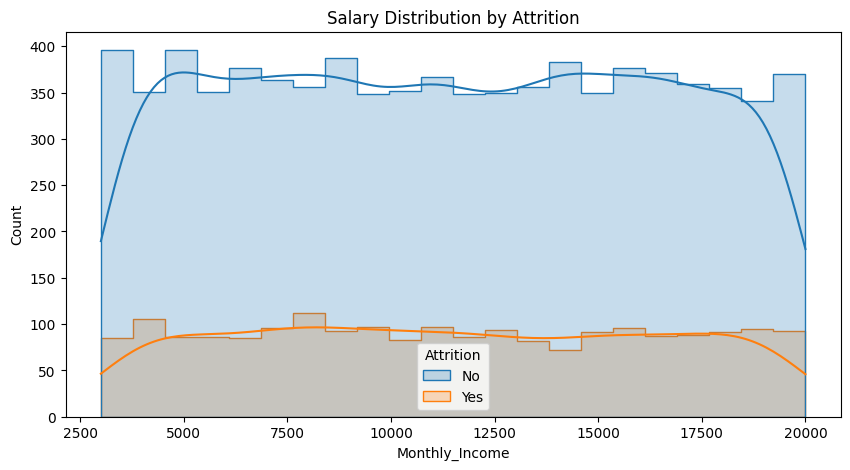

In [506]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df_emp_attrition,
    x='Monthly_Income',
    hue='Attrition',
    kde=True,
    element='step'
)

plt.title('Salary Distribution by Attrition')
plt.show()

In [507]:
df_emp_attrition.groupby('Attrition')['Monthly_Income'].mean()

,Monthly_Income
Attrition,
No,11436.385605
Yes,11438.043565


The plot shows that employees with and without attrition have a very similar salary distribution.

So, Monthly Income does not appear to strongly affect Attrition in this dataset.

##### Attrition by job satisfaction

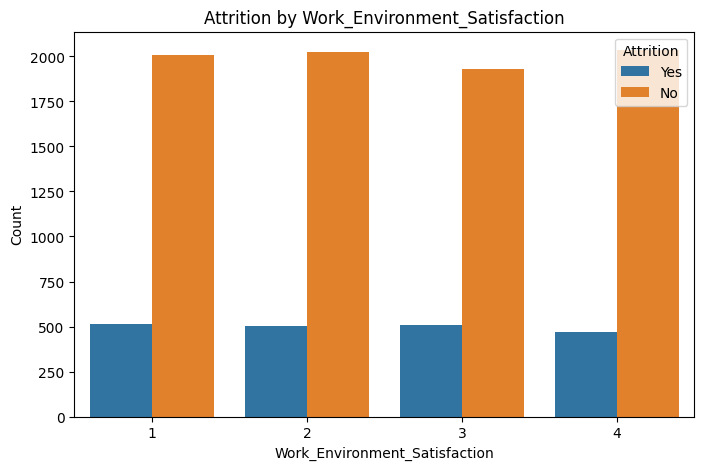

In [508]:
plt.figure(figsize=(8,5))

sns.countplot(x='Work_Environment_Satisfaction', hue='Attrition', data=df_emp_attrition)

plt.title('Attrition by Work_Environment_Satisfaction')
plt.xlabel('Work_Environment_Satisfaction')
plt.ylabel('Count')

plt.show()

In [509]:
pd.crosstab(
    df_emp_attrition['Work_Environment_Satisfaction'],
    df_emp_attrition['Attrition'],
    normalize='index'
) * 100

Attrition,No,Yes
Work_Environment_Satisfaction,,
1,79.556260,20.443740
2,80.150257,19.849743
3,79.212792,20.787208
4,81.180223,18.819777


The plot shows that attrition is fairly similar across all work environment satisfaction levels.

However, employees with satisfaction level 4 have slightly lower attrition compared to the other groups.

So, higher work environment satisfaction may slightly reduce attrition, but the effect is not very strong.

#### Multi-Variate Analysis

Text(0.5, 1.0, 'Marital Status = Divorced')

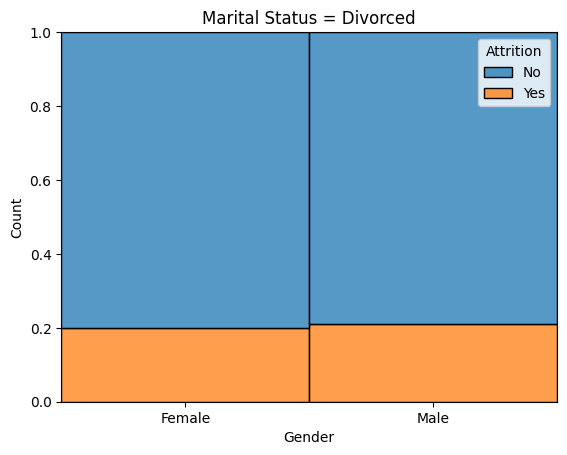

In [510]:
sns.histplot(data=df_emp_attrition[df_emp_attrition['Marital_Status'] == 'Divorced'], x='Gender', hue='Attrition', multiple='fill')
plt.title('Marital Status = Divorced')

The attrition rate is almost the same (only a slight difference) among divorced people irrespective of the gender

Text(0.5, 1.0, 'Marital_Status = Married')

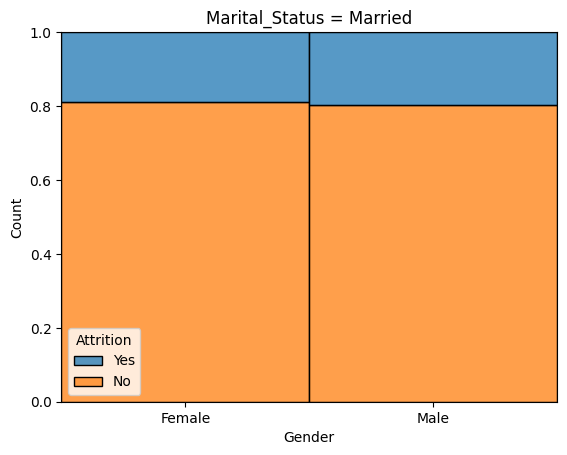

In [511]:
sns.histplot(data=df_emp_attrition[df_emp_attrition['Marital_Status'] == 'Married'], x='Gender', hue='Attrition', multiple='fill')
plt.title('Marital_Status = Married')

The attrition rate is almost the same (only a slight difference) among married people irrespective of the gender

Text(0.5, 1.0, 'Marital_Status = Single')

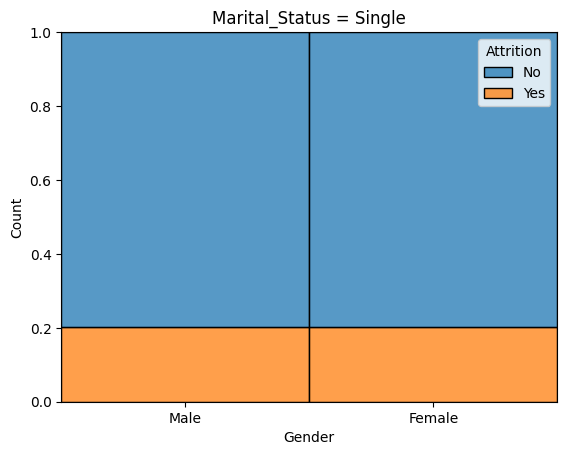

In [512]:
sns.histplot(data=df_emp_attrition[df_emp_attrition['Marital_Status'] == 'Single'], x='Gender', hue='Attrition', multiple='fill')
plt.title('Marital_Status = Single')

The attrition rate is almost the same (only a slight difference) among single people irrespective of the gender

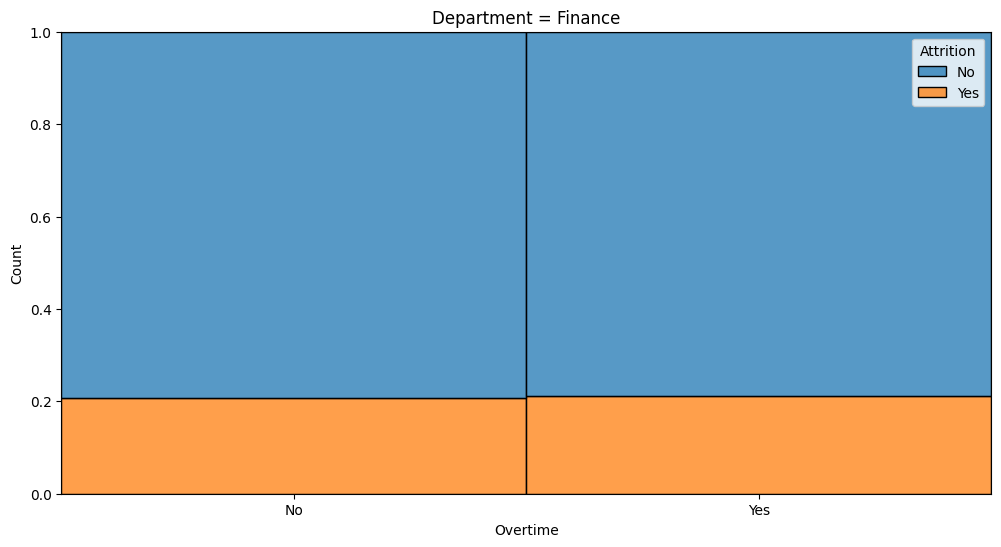

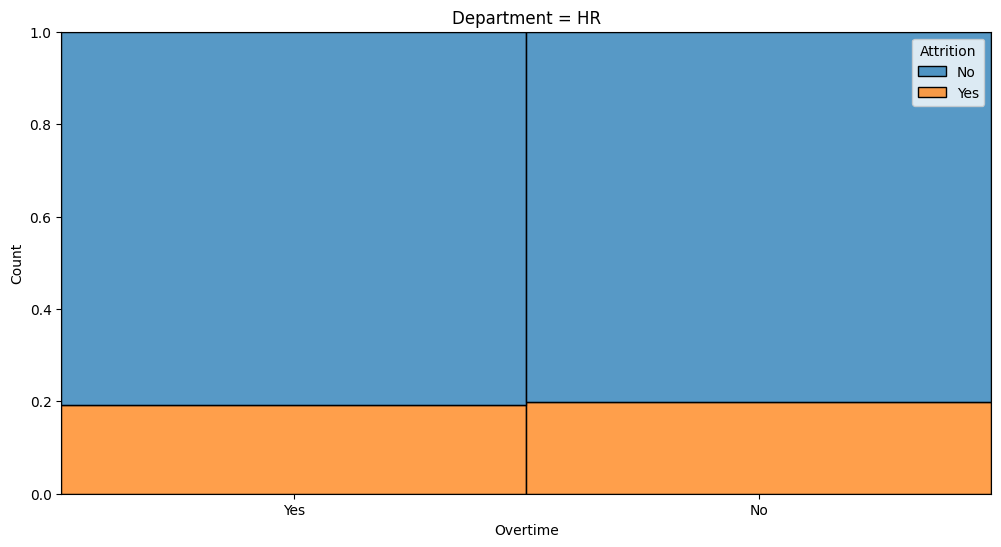

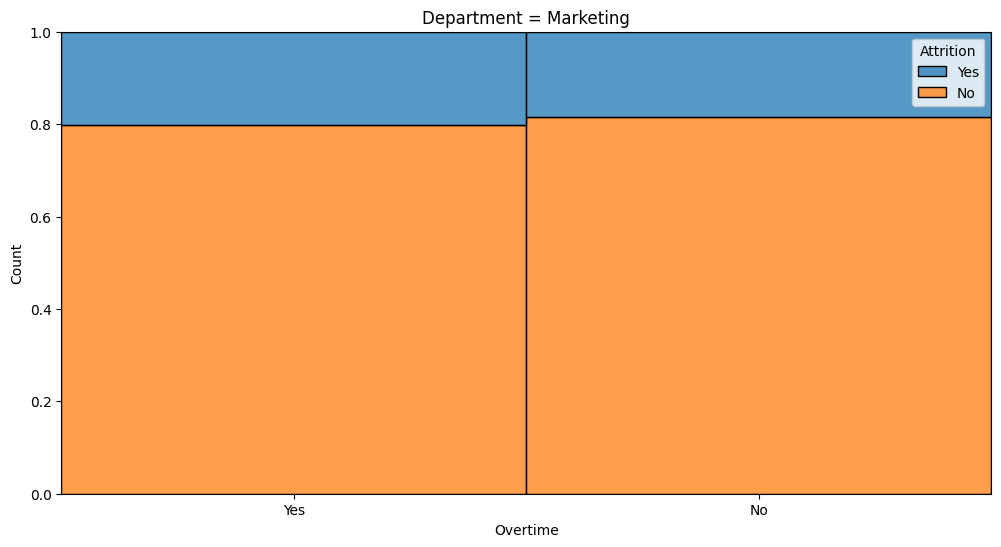

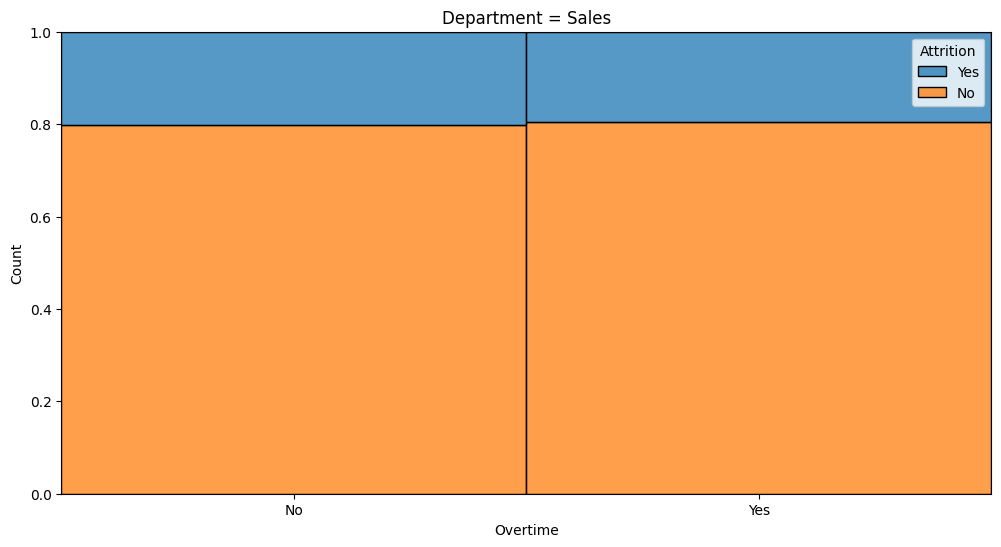

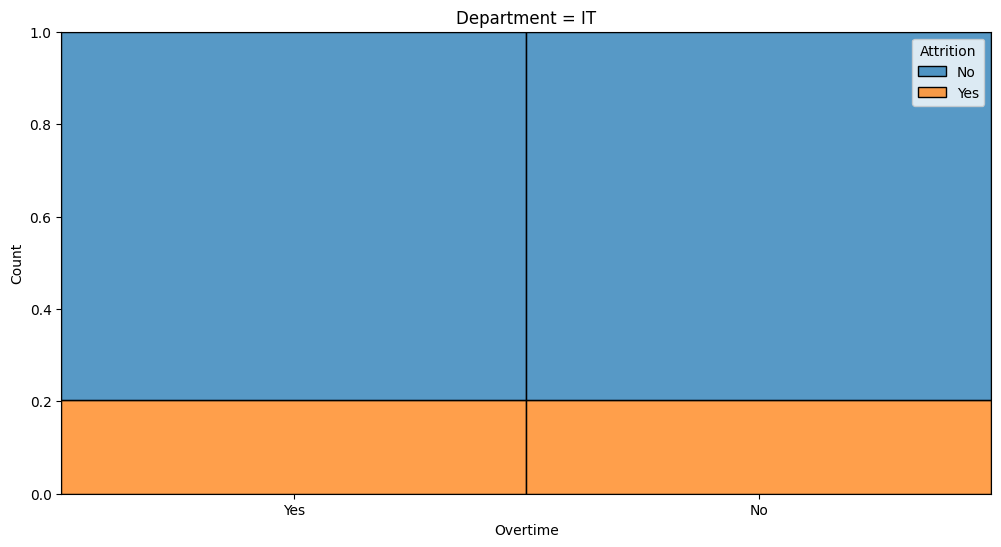

In [513]:
for dept in df_emp_attrition['Department'].unique():
  plt.figure(figsize=(12,6))
  plt.title(f'Department = {dept}')
  sns.histplot(data=df_emp_attrition[df_emp_attrition['Department'] == dept], x='Overtime', hue='Attrition', multiple='fill')


The attrition rate is almost the same (only a slight difference) for each Department irrespective of whether they do overtime work.

##### Correlation Heatmap

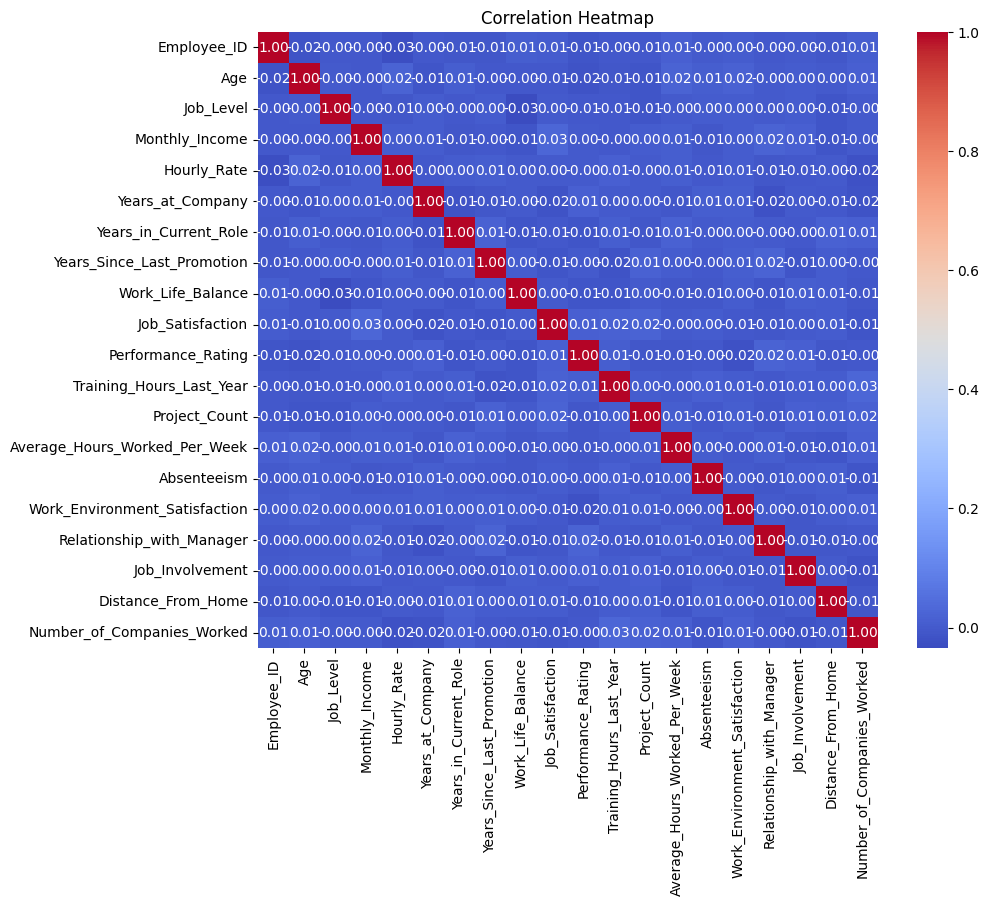

In [514]:
  # Correlation matrix
corr = df_emp_attrition.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

From the above Correlation heatmap, it is clear that none of the columns or features are highly correlated.

### 4. Data Preprocessing

Removing Employee_ID column since it does not have any significance.

In [515]:
df_emp_attrition = df_emp_attrition.drop('Employee_ID', axis=1)

##### Null value handling

In [516]:
df_emp_attrition.isna().sum()

,0
Age,0
Gender,0
Marital_Status,0
Department,0
Job_Role,0
Job_Level,0
Monthly_Income,0
Hourly_Rate,0
Years_at_Company,0
Years_in_Current_Role,0


There're no missing or null values in the data.

#### Encoding

Before feeding the training data to the ML model we've to encode the categorical columns:

In [517]:
from sklearn.preprocessing import OneHotEncoder

In [518]:
ohe = OneHotEncoder(drop='first', sparse_output=False)

In [519]:
encoded_data = ohe.fit_transform(df_emp_attrition[cat_cols])

In [520]:
encoded_df = pd.DataFrame(encoded_data, columns = ohe.get_feature_names_out(cat_cols), index=df_emp_attrition.index)

In [521]:
df_emp_attrition_encoded = df_emp_attrition.copy()

In [522]:
df_emp_attrition_encoded = pd.concat([df_emp_attrition_encoded, encoded_df], axis = 1)

In [523]:
df_emp_attrition_encoded.head(2)

,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,...,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager,Overtime_Yes,Attrition_Yes
0,58,Male,Single,Finance,Manager,5,7332,81,24,12,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,48,Female,Divorced,HR,Assistant,4,6069,55,18,7,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [524]:
df_emp_attrition_encoded = df_emp_attrition_encoded.drop(columns=cat_cols, axis=1)
df_emp_attrition_encoded.head(2)

,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,...,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager,Overtime_Yes,Attrition_Yes
0,58,5,7332,81,24,12,3,1,3,2,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,48,4,6069,55,18,7,5,1,2,2,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


#### Scaling

In [525]:
num_cols_new = [column for column in df_emp_attrition.columns if df_emp_attrition[column].dtype != 'O']
df_emp_attrition[num_cols_new]

,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
0,58,5,7332,81,24,12,3,1,3,2,74,9,48,16,4,1,1,49,3
1,48,4,6069,55,18,7,5,1,2,2,24,9,57,10,4,1,1,25,1
2,34,4,11485,65,6,4,3,4,5,1,63,3,55,1,1,4,3,21,1
3,27,4,18707,28,12,9,1,1,1,2,4,9,53,2,3,4,1,46,2
4,40,1,16398,92,3,9,1,3,4,3,62,1,54,11,1,1,1,43,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,22,5,4276,27,17,5,1,3,5,3,75,3,36,3,4,2,3,18,2
9996,35,3,10327,60,19,11,6,2,1,4,48,5,59,4,4,3,4,31,1
9997,23,3,12592,68,10,11,4,4,2,4,34,4,54,10,4,4,2,12,1
9998,42,3,9287,26,18,7,8,1,5,1,56,9,51,16,3,2,2,18,3


From the above observation it is clear that the Monthly_Income column is having values of thousands. And all the other columns are having values below 100. So we can consider scaling the Monthy_Income column.

In [526]:
from sklearn.preprocessing import StandardScaler

In [527]:
std_scaler = StandardScaler()

In [528]:
df_emp_attrition_encoded_scaled = df_emp_attrition_encoded.copy()

In [529]:
df_emp_attrition_encoded_scaled['Monthly_Income'] = std_scaler.fit_transform(df_emp_attrition_encoded[['Monthly_Income']])

In [530]:
df_emp_attrition_encoded_scaled.head(3)

,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,...,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager,Overtime_Yes,Attrition_Yes
0,58,5,-0.833228,81,24,12,3,1,3,2,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,48,4,-1.089608,55,18,7,5,1,2,2,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,34,4,0.009801,65,6,4,3,4,5,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0


#### Train-test splitting

Splitting the dataset into target and features

In [531]:
X = df_emp_attrition_encoded_scaled.drop('Attrition_Yes', axis=1)
y = df_emp_attrition_encoded_scaled['Attrition_Yes']

In [532]:
X.head(1)

,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,...,Marital_Status_Married,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager,Overtime_Yes
0,58,5,-0.833228,81,24,12,3,1,3,2,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Splitting the dataset into train and test sets

In [533]:
from sklearn.model_selection import train_test_split


In [534]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42
                                                    )

### 5. Model Building

#### Logistic Regression

In [535]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score


In [536]:
#initialize the model
lr_model = LogisticRegression()

#train the model
lr_model.fit(X=X_train, y=y_train)

#make predictions using the model or test the model
y_pred_lr = lr_model.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, average='weighted')
recall_lr = recall_score(y_test, y_pred_lr, average='weighted')
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

print(f'Accuracy : {acc_lr}')
print(f'Precision : {prec_lr}')
print(f'Recall : {recall_lr}')
print(f'F1 score : {f1_lr}')
print(f'Confusion matrix: \n{conf_matrix_lr}')

Accuracy : 0.796
Precision : 0.633616
Recall : 0.796
F1 score : 0.7055857461024498
Confusion matrix: 
[[1592    0]
 [ 408    0]]


#### Decision Tree

In [537]:
from sklearn.tree import DecisionTreeClassifier


In [538]:
#initialize the model
dt_model = DecisionTreeClassifier()

#train the model
dt_model.fit(X=X_train, y=y_train)

#make predictions using the model or test the model
y_pred_dt = dt_model.predict(X_test)

#Evaluating the model

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, average='weighted')
recall_dt = recall_score(y_test, y_pred_dt, average='weighted')
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

print(f'Accuracy : {acc_dt}')
print(f'Precision : {prec_dt}')
print(f'Recall : {recall_dt}')
print(f'F1 score : {f1_dt}')
print(f'Confusion matrix: \n{conf_matrix_dt}')

Accuracy : 0.6775
Precision : 0.686385574342713
Recall : 0.6775
F1 score : 0.681816317062403
Confusion matrix: 
[[1254  338]
 [ 307  101]]


#### Random Forest

In [539]:
from sklearn.ensemble import RandomForestClassifier

In [540]:
# initialize the model
rf_model = RandomForestClassifier(random_state=42)

# train the model
rf_model.fit(X=X_train, y=y_train)

# make predictions using the model
y_pred_rf = rf_model.predict(X_test)

# Evaluating the model
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print(f'Accuracy : {acc_rf}')
print(f'Precision : {prec_rf}')
print(f'Recall : {recall_rf}')
print(f'F1 score : {f1_rf}')
print(f'Confusion matrix: \n{conf_matrix_rf}')

Accuracy : 0.796
Precision : 0.633616
Recall : 0.796
F1 score : 0.7055857461024498
Confusion matrix: 
[[1592    0]
 [ 408    0]]


### 6. Model Evaluation

In [541]:
#Evaluating the model
predictions = {'Logistic Regression': y_pred_lr, 'Decison Tree Classifier': y_pred_dt, 'Random Forest Classifier': y_pred_rf}
for model, y_pred in predictions.items():
  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred, average='weighted')
  recall = recall_score(y_test, y_pred, average='weighted')
  conf_matrix = confusion_matrix(y_test, y_pred)
  f1 = f1_score(y_test, y_pred, average='weighted')

  print(model)
  print(f'Accuracy : {acc}')
  print(f'Precision : {prec}')
  print(f'Recall : {recall}')
  print(f'F1 score : {f1}')
  print(f'Confusion matrix: \n{conf_matrix} \n\n')

Logistic Regression
Accuracy : 0.796
Precision : 0.633616
Recall : 0.796
F1 score : 0.7055857461024498
Confusion matrix: 
[[1592    0]
 [ 408    0]] 


Decison Tree Classifier
Accuracy : 0.6775
Precision : 0.686385574342713
Recall : 0.6775
F1 score : 0.681816317062403
Confusion matrix: 
[[1254  338]
 [ 307  101]] 


Random Forest Classifier
Accuracy : 0.796
Precision : 0.633616
Recall : 0.796
F1 score : 0.7055857461024498
Confusion matrix: 
[[1592    0]
 [ 408    0]] 




#### Model Comparison

Ammong the 3 supervised classification models we used, LogisticRegression and RandomForest is giving the best accuracy score (both are having the same performance metric values). Decision Tree classifier is giving less accurate predictions.

### 7. Business Insights and Recommendations

#### Key Factors Influencing Attrition

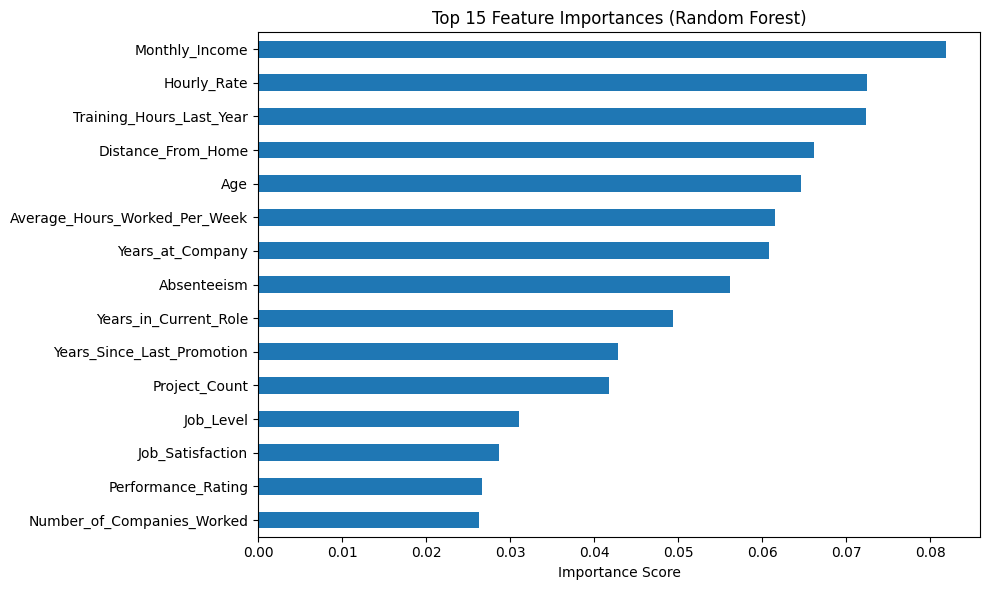

Monthly_Income                   0.081816
Hourly_Rate                      0.072404
Training_Hours_Last_Year         0.072363
Distance_From_Home               0.066184
Age                              0.064603
Average_Hours_Worked_Per_Week    0.061468
Years_at_Company                 0.060791
Absenteeism                      0.056163
Years_in_Current_Role            0.049355
Years_Since_Last_Promotion       0.042831
Project_Count                    0.041719
Job_Level                        0.031034
Job_Satisfaction                 0.028621
Performance_Rating               0.026688
Number_of_Companies_Worked       0.026285
dtype: float64


In [542]:
# Feature importance from Random Forest
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = feature_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_features)

#### High-risk employee profiles

In [543]:
# Filter attrited employees and describe their characteristics
attrited = df_emp_attrition[df_emp_attrition['Attrition'] == 'Yes']
stayed = df_emp_attrition[df_emp_attrition['Attrition'] == 'No']

# Compare means of numerical columns
print("Attrited employees (mean):")
print(attrited[num_cols_new].mean())
print("\nStayed employees (mean):")
print(stayed[num_cols_new].mean())

Attrited employees (mean):
Age                                 39.740611
Job_Level                            3.023035
Monthly_Income                   11438.043565
Hourly_Rate                         56.760641
Years_at_Company                    14.981472
Years_in_Current_Role                7.492739
Years_Since_Last_Promotion           4.460691
Work_Life_Balance                    2.536304
Job_Satisfaction                     3.044066
Performance_Rating                   2.534301
Training_Hours_Last_Year            49.557837
Project_Count                        5.019529
Average_Hours_Worked_Per_Week       44.431147
Absenteeism                          9.416124
Work_Environment_Satisfaction        2.468202
Relationship_with_Manager            2.482223
Job_Involvement                      2.538808
Distance_From_Home                  25.595393
Number_of_Companies_Worked           2.498247
dtype: float64

Stayed employees (mean):
Age                                 39.517181
Job_Level   

Departments with Higher Attrition Risk

In [544]:
dept_attrition = df_emp_attrition.groupby('Department')['Attrition'].value_counts().unstack()
dept_attrition['Attrition_Rate_%'] = (dept_attrition['Yes'] / dept_attrition.sum(axis=1) * 100).round(2)
dept_attrition['Total_Attrited'] = dept_attrition['Yes']
print(dept_attrition.sort_values('Attrition_Rate_%', ascending=False))

Attrition     No  Yes  Attrition_Rate_%  Total_Attrited
Department                                             
Finance     1575  415             20.85             415
IT          1526  390             20.35             390
Sales       1610  398             19.82             398
HR          1572  381             19.51             381
Marketing   1720  413             19.36             413


Finance dept has higher attrition risk

#### HR Intervention Strategies & Recommendations

- Improve Work Environment Satisfaction: Since satisfaction level showed a slight correlation with attrition, conducting regular employee satisfaction surveys and acting on the feedback can help reduce attrition.


- Focus on Younger Employees: Younger employees with fewer years of experience at the company appear to be at slightly higher risk. Mentorship programs and clear career growth paths can improve their retention.